<a href="https://colab.research.google.com/github/mw2304/SummerProject2026/blob/main/probablisticCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting annihilation probability over position

1. Loadings

In [1]:
%pip install uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 989.5/989.5 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.5/692.5 kB 25.4 MB/s eta 0:00:00


In [2]:
%pip install awkward_pandas

In [3]:

import os
import numpy as np
import pandas as pd
import uproot

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Flatten,
    Concatenate
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [4]:

ROOT_FILE = "new3merged.root"

file = uproot.open(ROOT_FILE)

print(file.keys())

['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']


In [5]:
tree = file["ThreeG_NCS"]
print(tree.keys())

['RunID', 'EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


2. Branches for Three gamma NCS

In [6]:
branches = [

    "RunID",
    "EventID",

    "GammaIndex",
    'NGammas',

    "X_mm",
    "Y_mm",
    "Z_mm",

    "EnergyDeposit_keV",
    "PreEnergy_keV",
    "PostEnergy_keV",

    "AnnihilX_mm",
    "AnnihilY_mm",
    "AnnihilZ_mm"

]

tree = file["ThreeG_NCS"]
df = tree.arrays(branches, library="pd")

print(df.head())

              RunID  EventID  GammaIndex  NGammas       X_mm       Y_mm  \
0  slurm_35882963_1        0           0        3  42.213463 -29.997831   
1  slurm_35882963_1        0           1        3 -39.140385  43.925343   
2  slurm_35882963_1        0           2        3  24.441950 -43.796162   
3  slurm_35882963_1       14           0        3  25.520941  44.251762   
4  slurm_35882963_1       14           1        3  50.743858  24.093874   

        Z_mm  EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV  AnnihilX_mm  \
0 -44.219231         382.314117     382.314117             0.0     4.632441   
1  13.321461         481.058167     481.058167             0.0     4.632441   
2   5.251225         158.625549     158.625549             0.0     4.632441   
3   1.901691         214.394302     214.394302             0.0     0.514280   
4 -56.104988         334.142273     334.142273             0.0     0.514280   

   AnnihilY_mm  AnnihilZ_mm  
0    -1.534016   -10.633850  
1    -1.534016

In [7]:
IMG_SIZE = 64

xmin = df.X_mm.min()
xmax = df.X_mm.max()

ymin = df.Y_mm.min()
ymax = df.Y_mm.max()

zmin = df.Z_mm.min()
zmax = df.Z_mm.max()

print(xmin, xmax)
print(ymin, ymax)
print(zmin, zmax)

-97.96681213378906 98.7254638671875
-96.54037475585938 98.2959213256836
-99.81287384033203 98.93370056152344


In [8]:

images = []
targets = []
plane_features = []

event_groups = df.groupby(["RunID", "EventID"], sort=False)



print(f"Building images from {event_groups.ngroups} events...")


for i, ((run_id, event_id), event) in enumerate(event_groups):

   #defining vector plane
    points = event.sort_values("GammaIndex")[["X_mm", "Y_mm", "Z_mm"]].values

    if len(points) != 3:
        continue

    P1 = points[0]
    P2 = points[1]
    P3 = points[2]

    # two vectors in the plane
    v1 = P2 - P1
    v2 = P3 - P1

    # plane normal
    normal = np.cross(v1, v2)

    # normalise and store
    if np.linalg.norm(normal) == 0:
        continue

    normal = normal / np.linalg.norm(normal)
    #plane_features.append(normal)

    # plane equation
    A, B, C = normal
    D = -np.dot(normal, P1)

    plane_features.append([A,B,C,D])



    # all hits with this RunID and EventID belong to one event

    image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)


    # Channel 0: XY projection

    H_xy, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [ymin, ymax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 0] = H_xy



    # Channel 1: XZ projection

    H_xz, _, _ = np.histogram2d(
        event["X_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 1] = H_xz



    # Channel 2: YZ projection

    H_yz, _, _ = np.histogram2d(
        event["Y_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[ymin, ymax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 2] = H_yz

    # Regression Targets


    annihil_x = event["AnnihilX_mm"].iloc[0]
    annihil_y = event["AnnihilY_mm"].iloc[0]
    annihil_z = event["AnnihilZ_mm"].iloc[0]

    target = [
        annihil_x,
        annihil_y,
        annihil_z,
    ]



    # Store image and target


    images.append(image)
    targets.append(target)
    #plane_features.append(normal)

    if (i + 1) % 1000 == 0:
        print(f"{i+1} events processed")


# Convert lists to arrays
images = np.array(images, dtype=np.float16)
targets = np.array(targets, dtype=np.float32)
plane_features = np.array(plane_features, dtype=np.float32)

print()
print("Images shape :", images.shape)
print("Targets shape:", targets.shape)
print("Plane features shape:", plane_features.shape)


Building images from 23684 events...
1000 events processed
2000 events processed
3000 events processed
4000 events processed
5000 events processed
6000 events processed
7000 events processed
8000 events processed
9000 events processed
10000 events processed
11000 events processed
12000 events processed
13000 events processed
14000 events processed
15000 events processed
16000 events processed
17000 events processed
18000 events processed
19000 events processed
20000 events processed
21000 events processed
22000 events processed
23000 events processed

Images shape : (23684, 64, 64, 3)
Targets shape: (23684, 3)
Plane features shape: (23684, 4)


Image normalisation

In [9]:
images /= np.max(images)

print(images.min())
print(images.max())

0.0
1.0


train test split

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp, plane_train, plane_temp = train_test_split(
    images,
    targets,
    plane_features,
    test_size=0.3,
    random_state=42,
    shuffle=True
)


print("Training images:", x_train.shape)
print("Temporary images:", x_temp.shape)

print("Training targets:", y_train.shape)
print("Temporary targets:", y_temp.shape)

print("Training planes:", plane_train.shape)
print("Temporary planes:", plane_temp.shape)

Training images: (16578, 64, 64, 3)
Temporary images: (7106, 64, 64, 3)
Training targets: (16578, 3)
Temporary targets: (7106, 3)
Training planes: (16578, 4)
Temporary planes: (7106, 4)


In [11]:
x_val, x_test, y_val, y_test, plane_val, plane_test = train_test_split(
    x_temp,
    y_temp,
    plane_temp,
    test_size=0.5,
    random_state=42,
    shuffle=True
)


print("Train:")
print(x_train.shape, y_train.shape, plane_train.shape)

print("\nValidation:")
print(x_val.shape, y_val.shape, plane_val.shape)

print("\nTest:")
print(x_test.shape, y_test.shape, plane_test.shape)

Train:
(16578, 64, 64, 3) (16578, 3) (16578, 4)

Validation:
(3553, 64, 64, 3) (3553, 3) (3553, 4)

Test:
(3553, 64, 64, 3) (3553, 3) (3553, 4)


scaler

In [12]:
from sklearn.preprocessing import StandardScaler

target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(y_train)

y_test_scaled = target_scaler.transform(y_test)


print(y_train_scaled[0])

[1.0122931 1.2554547 1.4039621]


building cnn

In [15]:
# Image input

image_input = Input(
    shape=(64,64,3),
    name="detector_image"
)


# First convolution block

x = Conv2D(
    16,
    (3,3),
    activation="relu"
)(image_input)

x = MaxPooling2D()(x)



# Second convolution block

x = Conv2D(
    32,
    (3,3),
    activation="relu"
)(x)

x = MaxPooling2D()(x)



# Third convolution block

x = Conv2D(
    64,
    (3,3),
    activation="relu"
)(x)

x = MaxPooling2D()(x)



# Convert feature maps into vector

x = Flatten()(x)

# Plane input

plane_input = Input(
    shape=(4,),
    name="plane_equation"
)


plane_features = Dense(
    16,
    activation="relu"
)(plane_input)

#Combining CNN and plane info
combined = Concatenate()(
    [x, plane_features]
)

#fully connected layers
combined = Dense(
    128,
    activation="relu"
)(combined)


combined = Dropout(0.3)(combined)
output = Dense(3)(combined)




In [17]:
model = Model(
    inputs=[
         image_input,
        plane_input
    ],
     outputs=output
)

In [18]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ detector_image      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 62, 62,    │        448 │ detector_image[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 31, 31,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 29, 29,    │      4,640 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 14, 14,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 12, 12,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 6, 6, 64)  │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plane_equation      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 2304)      │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │         80 │ plane_equation[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 2320)      │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │    297,088 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        387 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 321,139 (1.23 MB)

 Trainable params: 321,139 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

IGNORE CELL defining probabilotic loss functions

In [ ]:
def gaussian_nll(y_true, y_pred):

    # Split predictions into mean and uncertainty

    mu = y_pred[:, :3]      # predicted x,y,z
    sigma = y_pred[:, 3:]   # predicted uncertainty


    # Prevent sigma becoming negative or zero
    sigma = tf.nn.softplus(sigma) + 1e-6


    # Gaussian negative log likelihood
    loss = (
        0.5 * tf.square((y_true - mu) / sigma)
        + tf.math.log(sigma)
    )


    # Average over x,y,z
    return tf.reduce_mean(loss)

In [ ]:
lambda_plane = 0.1  # start small

def gaussian_nll_with_plane(y_true, y_pred, plane):

    # Predicted mean and uncertainty
    mu = y_pred[:, :3]
    sigma = y_pred[:, 3:]

    sigma = tf.nn.softplus(sigma) + 1e-6

    # Gaussian negative log likelihood
    nll = (
        0.5 * tf.square((y_true - mu) / sigma)
        + tf.math.log(sigma)
    )
    nll = tf.reduce_mean(nll)

    # Plane coefficients
    A = plane[:,0]
    B = plane[:,1]
    C = plane[:,2]
    D = plane[:,3]

    # Distance from predicted point to plane
    plane_residual = (
        A*mu[:,0] +
        B*mu[:,1] +
        C*mu[:,2] +
        D
    )

    plane_loss = tf.reduce_mean(tf.square(plane_residual))

    return nll + lambda_plane * plane_loss

compiling model

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=["mae"]
)

training model

In [20]:
history = model.fit(
    [x_train, plane_train],
    y_train,
    validation_data=(
        [x_val, plane_val],
        y_val
    ),
    epochs=50,
    batch_size=32
)

Epoch 1/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 7.7049 - mae: 2.1647 - val_loss: 4.6645 - val_mae: 1.7933
Epoch 2/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.0945 - mae: 1.8619 - val_loss: 4.5248 - val_mae: 1.7654
Epoch 3/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 4.9690 - mae: 1.8394 - val_loss: 4.4324 - val_mae: 1.7463
Epoch 4/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.8173 - mae: 1.8084 - val_loss: 4.3268 - val_mae: 1.7216
Epoch 5/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.6490 - mae: 1.7725 - val_loss: 4.1427 - val_mae: 1.6797
Epoch 6/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4.4922 - mae: 1.7391 - val_loss: 4.0213 - val_mae: 1.6487
Epoch 7/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.3804 - mae: 1.7123 - val_loss: 4.0169 - val_mae: 1.6440
Epoch 8/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.2831 - mae: 1.6892 - val_loss: 3.9125 - val_mae: 1.6178
Epoch 9/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - 

plotting loss

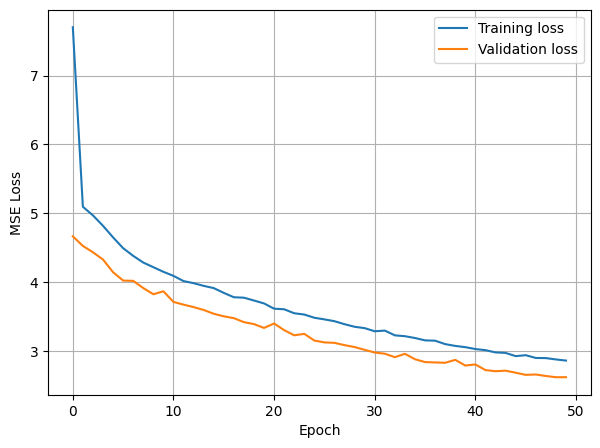

In [22]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7,5))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()
plt.show()

making predictions

In [23]:
prediction = model.predict(
    [
        x_test,
        plane_test
    ]
)
print(prediction.shape)

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
(3553, 3)


In [24]:
normal = plane_test[:, :3]

D = plane_test[:, 3]

distance = (
    np.sum(normal * prediction, axis=1) + D
)

prediction_on_plane = (
    prediction
    - distance[:, None] * normal
)

In [25]:
from sklearn.metrics import mean_absolute_error

mae_original = mean_absolute_error(
    y_test,
    prediction
)

mae_projected = mean_absolute_error(
    y_test,
    prediction_on_plane
)

print("Original CNN MAE:",
      mae_original,
      "mm")

print("Plane-projected MAE:",
      mae_projected,
      "mm")

Original CNN MAE: 1.278871774673462 mm
Plane-projected MAE: 1.4423332214355469 mm


In [26]:
original_error = prediction - y_test

projected_error = prediction_on_plane - y_test


original_distance = np.sqrt(
    np.sum(original_error**2, axis=1)
)

projected_distance = np.sqrt(
    np.sum(projected_error**2, axis=1)
)


print("Mean 3D reconstruction error BEFORE projection:",
      np.mean(original_distance),
      "mm")

print("Mean 3D reconstruction error AFTER projection:",
      np.mean(projected_distance),
      "mm")

Mean 3D reconstruction error BEFORE projection: 2.5638816 mm
Mean 3D reconstruction error AFTER projection: 2.896739 mm


In [27]:
print("Median 3D error BEFORE projection:",
      np.median(original_distance),
      "mm")

print("Median 3D error AFTER projection:",
      np.median(projected_distance),
      "mm")

Median 3D error BEFORE projection: 2.4299648 mm
Median 3D error AFTER projection: 2.256229 mm


In [28]:
projected_plane_distance = (
    np.sum(
        normal * prediction_on_plane,
        axis=1
    )
    + D
)

print(
    "Mean distance of projected predictions from plane:",
    np.mean(np.abs(projected_plane_distance)),
    "mm"
)

Mean distance of projected predictions from plane: 2.0192898e-07 mm


In [29]:
print("\n===== CNN PERFORMANCE =====")

print(
    "MAE before projection:",
    mae_original,
    "mm"
)

print(
    "MAE after projection:",
    mae_projected,
    "mm"
)

print(
    "Mean 3D error before projection:",
    np.mean(original_distance),
    "mm"
)

print(
    "Mean 3D error after projection:",
    np.mean(projected_distance),
    "mm"
)

print(
    "Median 3D error before projection:",
    np.median(original_distance),
    "mm"
)

print(
    "Median 3D error after projection:",
    np.median(projected_distance),
    "mm"
)


===== CNN PERFORMANCE =====
MAE before projection: 1.278871774673462 mm
MAE after projection: 1.4423332214355469 mm
Mean 3D error before projection: 2.5638816 mm
Mean 3D error after projection: 2.896739 mm
Median 3D error before projection: 2.4299648 mm
Median 3D error after projection: 2.256229 mm


IGNORE BELOW

checking pred

In [ ]:
for i in range(5):

    print("Event", i)

    print(
        "True:",
        y_test[i]
    )

    print(
        "Predicted:",
        mu_mm[i]
    )

    print(
        "Uncertainty:",
        sigma_mm[i]
    )

    print()

Event 0
True: [ 1.1561439e+00  2.9678505e-03 -9.0266495e+00]


NameError: name 'mu_mm' is not defined

calculating position error and MAE

In [ ]:
position_error = mu_mm - y_test


distance_error = np.sqrt(
    position_error[:,0]**2 +
    position_error[:,1]**2 +
    position_error[:,2]**2
)


print(
    "Mean annihilation position error:",
    np.mean(distance_error),
    "mm"
)

Mean annihilation position error: 2.4495685 mm


In [ ]:
from sklearn.metrics import mean_absolute_error


mae_x = mean_absolute_error(
    y_test[:,0],
    mu_mm[:,0]
)

mae_y = mean_absolute_error(
    y_test[:,1],
    mu_mm[:,1]
)

mae_z = mean_absolute_error(
    y_test[:,2],
    mu_mm[:,2]
)


print("X MAE:", mae_x, "mm")
print("Y MAE:", mae_y, "mm")
print("Z MAE:", mae_z, "mm")

X MAE: 1.1208953857421875 mm
Y MAE: 1.4153200387954712 mm
Z MAE: 1.1167327165603638 mm


In [ ]:
average_uncertainty = np.mean(
    sigma_mm,
    axis=1
)


correlation = np.corrcoef(
    average_uncertainty,
    distance_error
)[0,1]


print(
    "Uncertainty-error correlation:",
    correlation
)

Uncertainty-error correlation: 0.5697584054237466


plot reconstuction

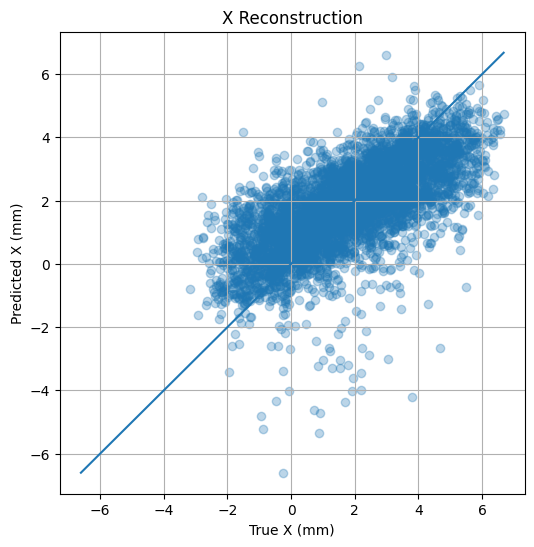

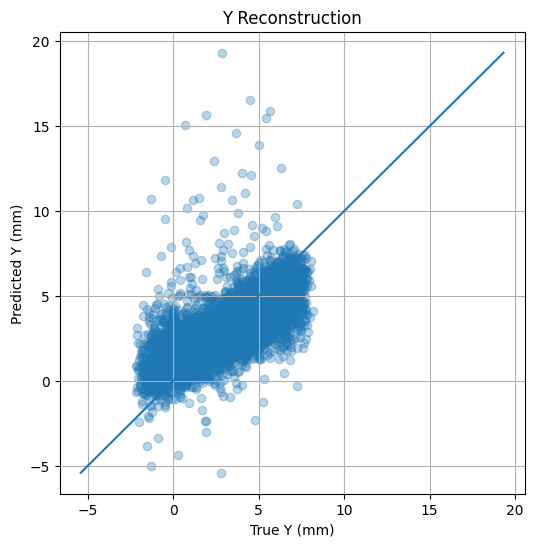

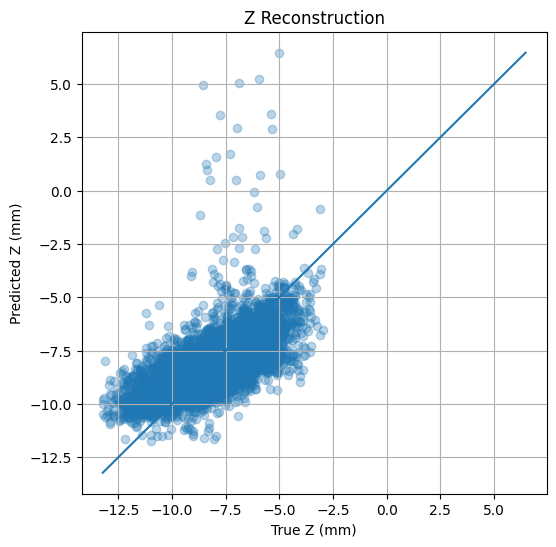

In [ ]:
import matplotlib.pyplot as plt


coordinates = ["X", "Y", "Z"]


for i, coord in enumerate(coordinates):

    plt.figure(figsize=(6,6))

    plt.scatter(
        y_test[:,i],
        mu_mm[:,i],
        alpha=0.3
    )

    # perfect prediction line
    minimum = min(
        y_test[:,i].min(),
        mu_mm[:,i].min()
    )

    maximum = max(
        y_test[:,i].max(),
        mu_mm[:,i].max()
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum]
    )

    plt.xlabel(f"True {coord} (mm)")
    plt.ylabel(f"Predicted {coord} (mm)")
    plt.title(f"{coord} Reconstruction")

    plt.grid()
    plt.show()

residuals

In [ ]:
residuals = mu_mm - y_test

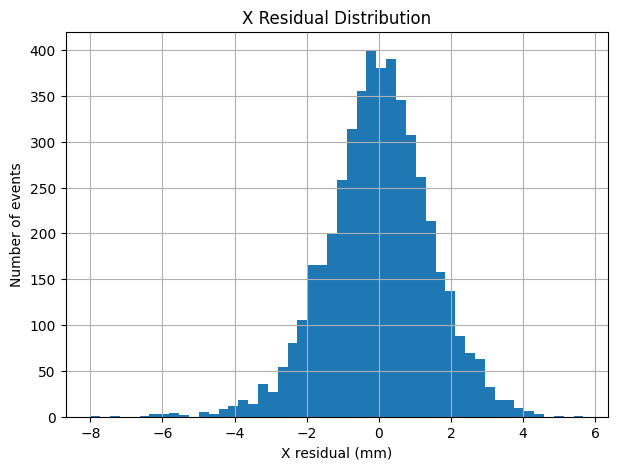

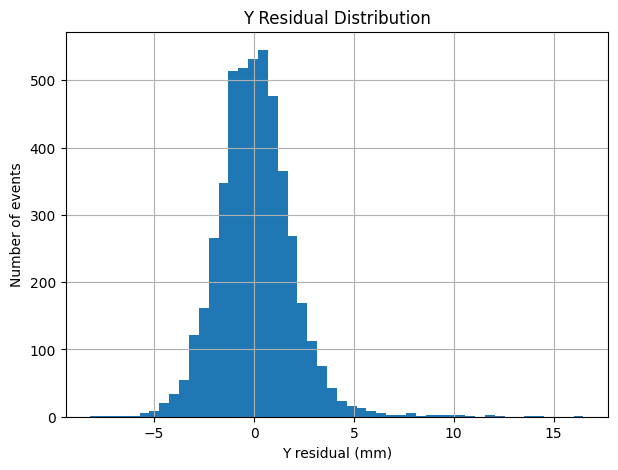

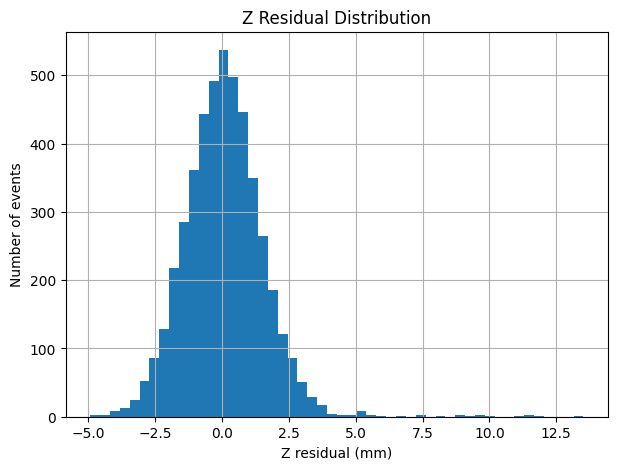

In [ ]:
for i, coord in enumerate(coordinates):

    plt.figure(figsize=(7,5))

    plt.hist(
        residuals[:,i],
        bins=50
    )

    plt.xlabel(
        f"{coord} residual (mm)"
    )

    plt.ylabel(
        "Number of events"
    )

    plt.title(
        f"{coord} Residual Distribution"
    )

    plt.grid()
    plt.show()

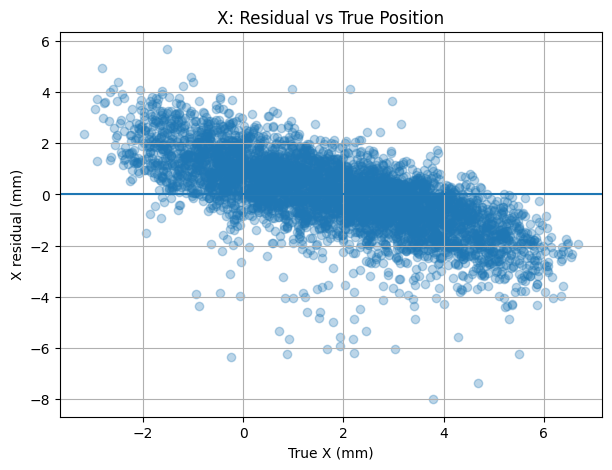

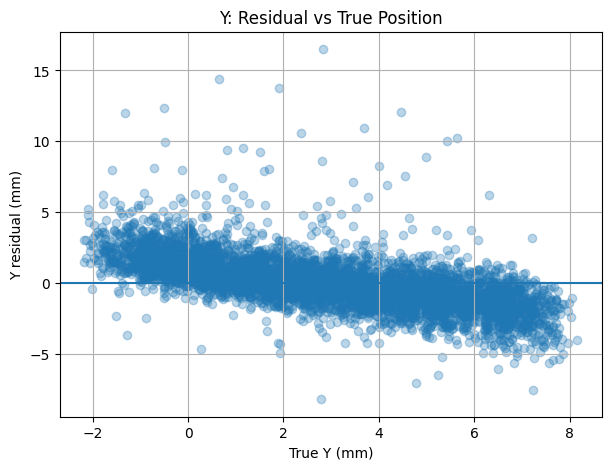

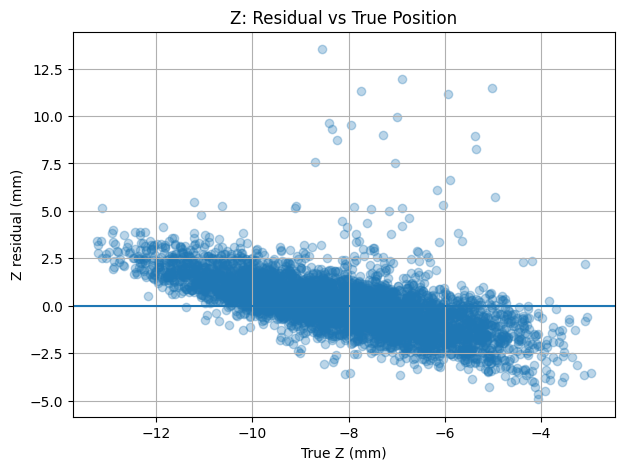

In [ ]:
for i, coord in enumerate(coordinates):

    plt.figure(figsize=(7,5))

    plt.scatter(
        y_test[:,i],
        residuals[:,i],
        alpha=0.3
    )

    plt.axhline(
        0
    )

    plt.xlabel(
        f"True {coord} (mm)"
    )

    plt.ylabel(
        f"{coord} residual (mm)"
    )

    plt.title(
        f"{coord}: Residual vs True Position"
    )

    plt.grid()
    plt.show()

uncenrtainity vs erorr

In [ ]:
mean_sigma = np.mean(
    sigma_mm,
    axis=1
)

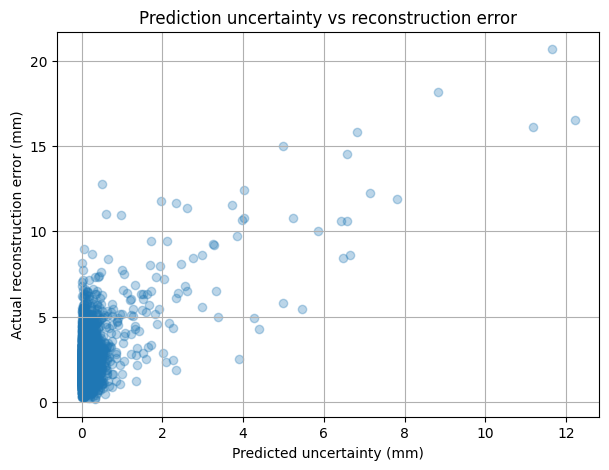

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    mean_sigma,
    distance_error,
    alpha=0.3
)

plt.xlabel(
    "Predicted uncertainty (mm)"
)

plt.ylabel(
    "Actual reconstruction error (mm)"
)

plt.title(
    "Prediction uncertainty vs reconstruction error"
)

plt.grid()
plt.show()

In [ ]:
print(
    "Mean 3D position error:",
    np.mean(distance_error),
    "mm"
)


print(
    "Median 3D position error:",
    np.median(distance_error),
    "mm"
)


print(
    "Mean uncertainty:",
    np.mean(mean_sigma),
    "mm"
)

Mean 3D position error: 2.4495685 mm
Median 3D position error: 2.2329543 mm
Mean uncertainty: 0.17646415526935635 mm


In [ ]:
for i in range(5):

    print("Event", i)

    print("Error:",
          distance_error[i],
          "mm")

    print("Uncertainty:",
          sigma_mm[i])

    print()

Event 0
Error: 1.4224803 mm
Uncertainty: [0.02534806 0.12704618 0.00715382]

Event 1
Error: 4.378827 mm
Uncertainty: [0.33385142 0.00972183 0.01323323]

Event 2
Error: 0.816648 mm
Uncertainty: [0.06610352 0.02963885 0.26607149]

Event 3
Error: 3.0224042 mm
Uncertainty: [0.06294645 0.66328573 0.17308489]

Event 4
Error: 2.2180133 mm
Uncertainty: [0.11790598 0.04179913 0.10846544]



In [ ]:
mean_sigma = np.mean(
    sigma_mm,
    axis=1
)

correlation = np.corrcoef(
    mean_sigma,
    distance_error
)[0,1]

print(
    "Uncertainty-error correlation:",
    correlation
)

Uncertainty-error correlation: 0.5697584054237466


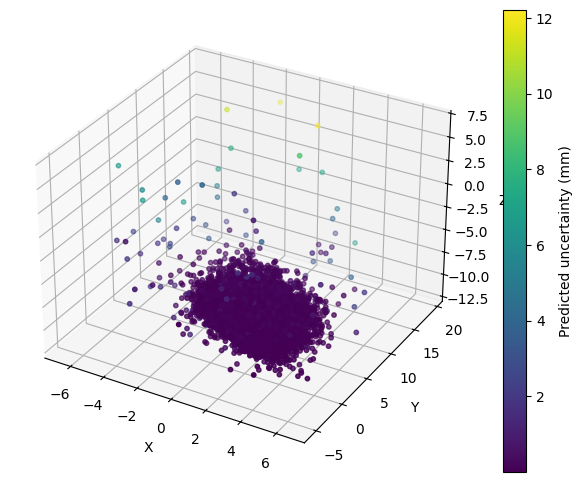

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    mu_mm[:,0],
    mu_mm[:,1],
    mu_mm[:,2],
    c=mean_sigma,
    s=10
)

plt.colorbar(sc, label="Predicted uncertainty (mm)")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

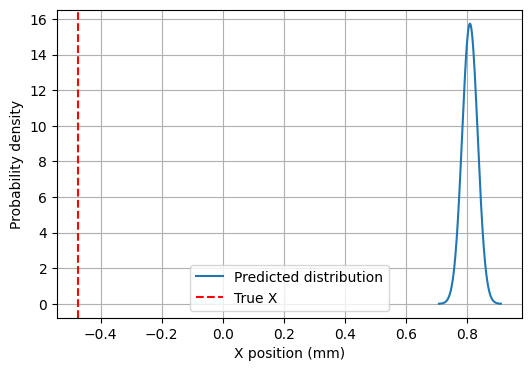

In [ ]:
event = 0

x = np.linspace(
    mu_mm[event,0]-4*sigma_mm[event,0],
    mu_mm[event,0]+4*sigma_mm[event,0],
    200
)

pdf = (
    1/(sigma_mm[event,0]*np.sqrt(2*np.pi))
    * np.exp(-(x-mu_mm[event,0])**2/(2*sigma_mm[event,0]**2))
)

plt.figure(figsize=(6,4))

plt.plot(x, pdf, label="Predicted distribution")

plt.axvline(
    y_test[event,0],
    color="red",
    linestyle="--",
    label="True X"
)

plt.xlabel("X position (mm)")
plt.ylabel("Probability density")

plt.legend()
plt.grid()

plt.show()

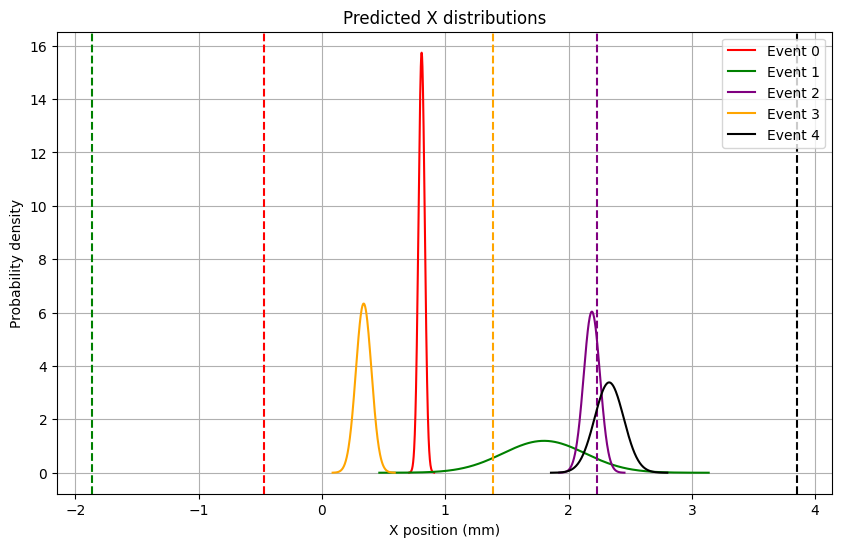

In [ ]:
plt.figure(figsize=(10,6))

events = [0, 1, 2, 3, 4]

colours = ["red", "green", "purple", "orange", "black"]

for event, colour in zip(events, colours):

    x = np.linspace(
        mu_mm[event,0] - 4*sigma_mm[event,0],
        mu_mm[event,0] + 4*sigma_mm[event,0],
        200
    )

    pdf = (
        1/(sigma_mm[event,0]*np.sqrt(2*np.pi))
        * np.exp(-(x-mu_mm[event,0])**2/(2*sigma_mm[event,0]**2))
    )

    # predicted distribution
    plt.plot(
        x,
        pdf,
        color=colour,
        label=f"Event {event}"
    )

    # true position (same colour, dashed)
    plt.axvline(
        y_test[event,0],
        color=colour,
        linestyle="--"
    )

plt.xlabel("X position (mm)")
plt.ylabel("Probability density")
plt.title("Predicted X distributions")

plt.legend()
plt.grid()
plt.show()

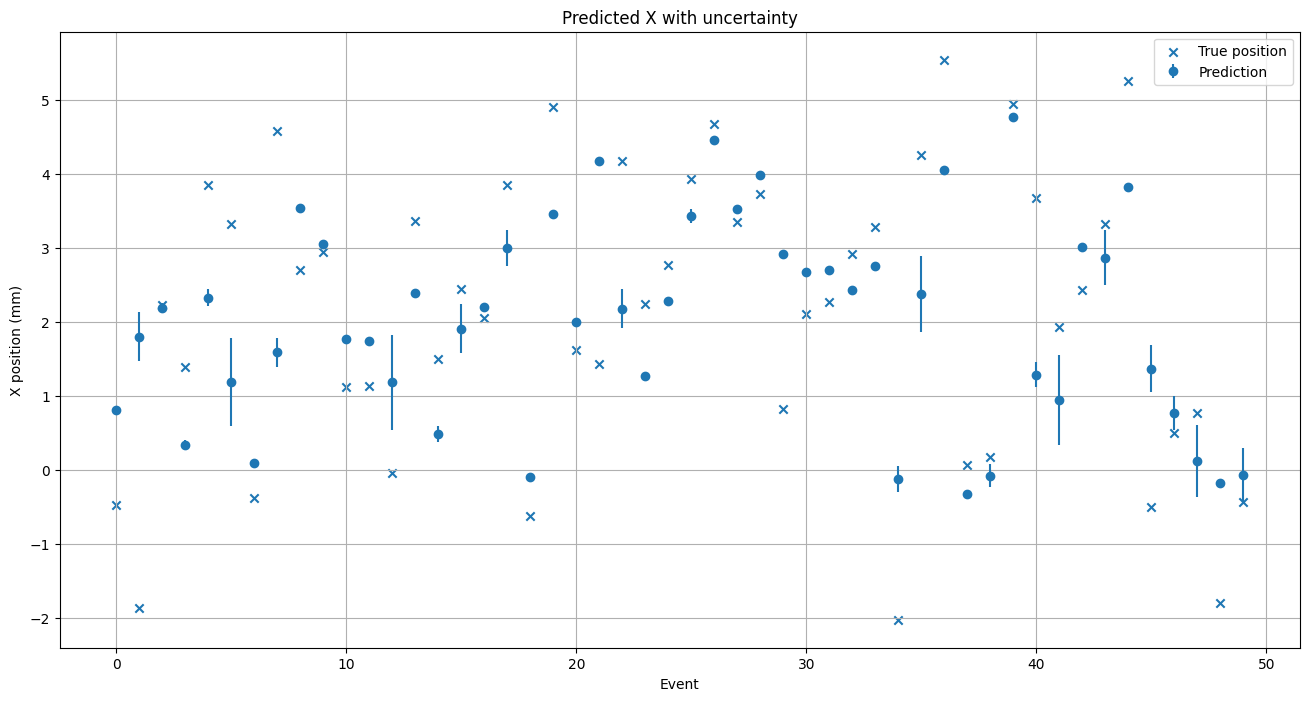

In [ ]:
idx = np.arange(50)

plt.figure(figsize=(16,8))

plt.errorbar(
    idx,
    mu_mm[:50,0],
    yerr=sigma_mm[:50,0],
    fmt='o',
    label="Prediction"
)

plt.scatter(
    idx,
    y_test[:50,0],
    marker='x',
    label="True position"
)

plt.xlabel("Event")
plt.ylabel("X position (mm)")
plt.title("Predicted X with uncertainty")
plt.legend()
plt.grid()
plt.show()